Different Streaming Techniques

- stream() - synchronous
- astream() - asynchronous

addition params in streaming modes 
- values: streams full state of the graph
- updates: stream updates to the state of the graph

Building the Graph

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
#Reducers
from typing import Annotated
from langgraph.graph.message import add_messages,AnyMessage
from langchain.messages import HumanMessage

In [2]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

In [3]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022D1C080F80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022D1C2DAA80>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
def chatbot(state: State):
    return {"messages":[llm.invoke(state['messages'])]}

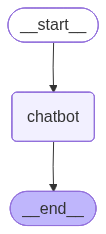

In [5]:
graph = StateGraph(State)

#adding node
graph.add_node("chatbot",chatbot)

#adding edges
graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)

memory = MemorySaver()
#compiling
graph_builder = graph.compile(checkpointer=memory)

#displaying
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

Streaming the responses

In [13]:
config = {"configurable":{'thread_id':'2'}}

1. stream

In [14]:
for chunk in graph_builder.stream({'messages':'Hi My Name is Arya i like football'},config,stream_mode="updates"):
    print(chunk)

{'chatbot': {'messages': [AIMessage(content="Hello Arya, nice to meet you. Football is a fantastic sport, isn't it? Which team or player is your favorite? Do you play football yourself or are you more of a fan who likes to watch and follow the game?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 44, 'total_tokens': 93, 'completion_time': 0.087109087, 'completion_tokens_details': None, 'prompt_time': 0.002508885, 'prompt_tokens_details': None, 'queue_time': 0.158003294, 'total_time': 0.089617972}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2787-4937-70f2-9669-7ba8604a7177-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 49, 'total_tokens': 93})]}}


In [15]:
for chunk in graph_builder.stream({'messages':'i also like football'},config,stream_mode="updates"):
    print(chunk)

{'chatbot': {'messages': [AIMessage(content='You must be talking about American football, since it\'s also known as "football" in some parts of the world. If that\'s the case, do you have a favorite team in the NFL (National Football League) or a specific player you like to watch?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 106, 'total_tokens': 160, 'completion_time': 0.104816153, 'completion_tokens_details': None, 'prompt_time': 0.006784176, 'prompt_tokens_details': None, 'queue_time': 0.158933143, 'total_time': 0.111600329}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2788-786e-7d81-bc3a-8760184e9640-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 54, 'total_tokens': 160})]}}


In [16]:
for chunk in graph_builder.stream({'messages':'i was talking about european football american football is not football its fake real football is european football'},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi My Name is Arya i like football', additional_kwargs={}, response_metadata={}, id='f0e0d74f-6521-4ca8-8559-922de7bed6ae'), AIMessage(content="Hello Arya, nice to meet you. Football is a fantastic sport, isn't it? Which team or player is your favorite? Do you play football yourself or are you more of a fan who likes to watch and follow the game?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 44, 'total_tokens': 93, 'completion_time': 0.087109087, 'completion_tokens_details': None, 'prompt_time': 0.002508885, 'prompt_tokens_details': None, 'queue_time': 0.158003294, 'total_time': 0.089617972}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2787-4937-70f2-9669-7ba8604a7177-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'outpu

2. astream

In [19]:
config = {"configurable":{"thread_id":"3"}}
async for event in graph_builder.astream_events({"messages":["Hi my name is Arya and i like to play BGMI"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi my name is Arya and i like to play BGMI']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f2790-f0af-7e73-ac28-bdba2f1885d7', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is Arya and i like to play BGMI', additional_kwargs={}, response_metadata={}, id='30ab07d3-8505-4cf0-aff6-eb33786b33dd')]}}, 'name': 'chatbot', 'tags': ['graph:step:1'], 'run_id': '019f2790-f0b2-7c63-b519-e78be30e670d', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'chatbot', 'langgraph_triggers': ('branch:to:chatbot',), 'langgraph_path': ('__pregel_pull', 'chatbot'), 'langgraph_checkpoint_ns': 'chatbot:3333bddf-6b2e-e829-bc5f-c0df6cdcd239'}, 'parent_ids': ['019f2790-f0af-7e73-ac28-bdba2f1885d7']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessa